In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import mne
from scipy.optimize import minimize
from scipy.stats import norm, skewnorm
from math import ceil
import pandas as pd

from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss


repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Upload data

In [2]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)

models_dict, trajectories_dict, binarized_audibilities_dict = {}, {}, {}
    
for part in tqdm(range(20)):

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        trajectories_dict[part] = state_train
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # sort audibilities according to SNR
    sorted_audibilities = {cat: [] for cat in categories}
    binarized_audibilities = {cat: [] for cat in categories}
    for cat in categories:
        cat_indices = np.where(snr == (cat + 1))[0]
        sorted_audibilities[cat] = audibility[cat_indices]
        binarized_audibilities[cat] = (sorted_audibilities[cat] >= 2).astype(int)
    binarized_audibilities_dict[part] = binarized_audibilities

    # load model parameters 
    model = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path + f"/GainModulatedModel_part{part}_params"
    model.load_params(param_path)
    models_dict[part] = model

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_122900/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_122900/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_122900/831752060.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_122900/831752060.py:14: RuntimeWarning: 

# Simulate trajectories from fitted models

In [3]:
simul_trajectories_dict = {}
n_trials = 10000
for part in tqdm(range(20)):
    categories = list(trajectories_dict[part].keys())
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
    input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}
    model = models_dict[part]
    measures = model.measure_simulations(input_series=input_series) #, initial_states = {cat: np.repeat(trajectories_dict[part][cat][:, 75].flatten(), 5) for cat in categories})
    simul_trajectories_dict[part] = measures

  0%|          | 0/20 [00:00<?, ?it/s]

# Compute the loglikelihood of the resting state model

In [4]:
one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}

logliks_rest, logliks_high, logliks_ratio = {}, {}, {}
logliks_rest_ref, logliks_high_ref, logliks_ratio_ref = {}, {}, {}
for part in tqdm(range(20)):
    model = models_dict[part]
    measures_simul = simul_trajectories_dict[part]
    measures_empirical = trajectories_dict[part]
    binarized_audibilities = binarized_audibilities_dict[part]

    # populate logliks computed on empirical data
    logliks_rest_this_part = {cat: [] for cat in measures_empirical.keys()}
    logliks_high_this_part = {cat: [] for cat in measures_empirical.keys()}
    logliks_ratio_this_part = {cat: [] for cat in measures_empirical.keys()}
    for cat in tqdm(measures_empirical.keys(), desc=f'Part {part}', leave=True):
        for trial in measures_empirical[cat]:

            # false_rest_measures = {0: trial[np.newaxis, 75:90]}
            # false_rest_inputs = {0: np.zeros_like(trial[np.newaxis, 75:90])}
            # logliks_rest_this_part[cat].append(model.loglikelihood(false_rest_measures, false_rest_inputs))

            # false_high_measures = {cat: trial[np.newaxis, 75:90]}
            # false_high_inputs = {cat: np.ones_like(trial[np.newaxis, 75:90])}
            # logliks_high_this_part[cat].append(model.loglikelihood(false_high_measures, false_high_inputs))

            false_rest_measures = {0: trial[np.newaxis, 80:100]}
            false_rest_inputs = {0: np.zeros_like(trial[np.newaxis, 80:100])}
            logliks_rest_this_part[cat].append(model.loglikelihood(false_rest_measures, false_rest_inputs))

            false_high_measures = {5: trial[np.newaxis, 80:100]}
            false_high_inputs = {5: np.ones_like(trial[np.newaxis, 80:100])}
            logliks_high_this_part[cat].append(model.loglikelihood(false_high_measures, false_high_inputs))

            logliks_ratio_this_part[cat].append(logliks_high_this_part[cat][-1] - logliks_rest_this_part[cat][-1])

    logliks_rest[part] = logliks_rest_this_part
    logliks_high[part] = logliks_high_this_part
    logliks_ratio[part] = logliks_ratio_this_part

    # # populate logliks computed on simulated data
    # logliks_rest_ref_this_part = []
    # logliks_high_ref_this_part = []
    # logliks_ratio_ref_this_part = []
    # for trial in tqdm(measures_simul[0], desc=f'Part {part} - Simulated', leave=True):

    #     true_rest_measures = {0: trial[np.newaxis, 75:90]}
    #     true_rest_inputs = {0: np.zeros_like(trial[np.newaxis, 75:90])}
    #     logliks_rest_ref_this_part.append(model.loglikelihood(true_rest_measures, true_rest_inputs))

    #     true_high_measures = {5: trial[np.newaxis, 75:90]}
    #     true_high_inputs = {5: np.ones_like(trial[np.newaxis, 75:90])}
    #     logliks_high_ref_this_part.append(model.loglikelihood(true_high_measures, true_high_inputs))

    #     logliks_ratio_ref_this_part.append(logliks_high_ref_this_part[-1] - logliks_rest_ref_this_part[-1])

    # logliks_rest_ref[part] = logliks_rest_ref_this_part
    # logliks_high_ref[part] = logliks_high_ref_this_part
    # logliks_ratio_ref[part] = logliks_ratio_ref_this_part

  0%|          | 0/20 [00:00<?, ?it/s]

Part 0:   0%|          | 0/6 [00:00<?, ?it/s]

Part 1:   0%|          | 0/6 [00:00<?, ?it/s]

Part 2:   0%|          | 0/6 [00:00<?, ?it/s]

Part 3:   0%|          | 0/6 [00:00<?, ?it/s]

...

Part 15:   0%|          | 0/6 [00:00<?, ?it/s]

Part 16:   0%|          | 0/6 [00:00<?, ?it/s]

Part 17:   0%|          | 0/6 [00:00<?, ?it/s]

Part 18:   0%|          | 0/6 [00:00<?, ?it/s]

Part 19:   0%|          | 0/6 [00:00<?, ?it/s]

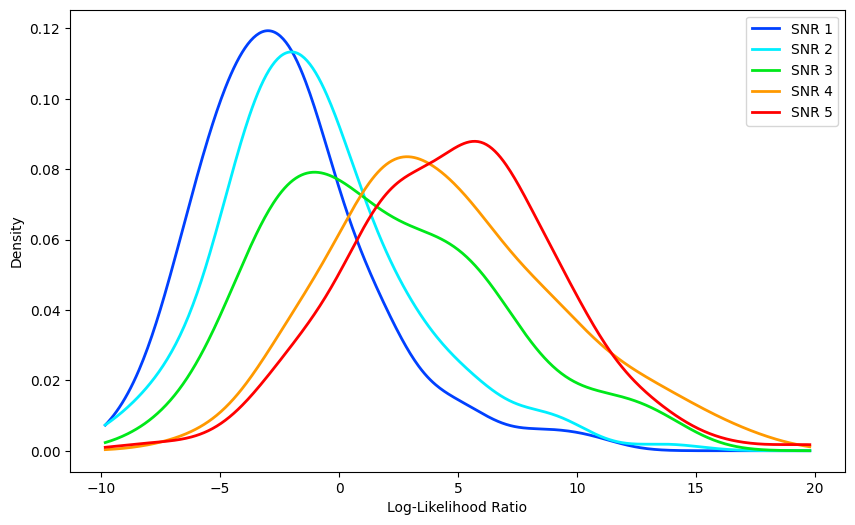

In [5]:
from scipy.stats import gaussian_kde


part = 13

plt.figure(figsize=(10, 6))

# Define a common evaluation grid for smooth plotting
# This ensures all KDE curves span the same range
# all_data = np.concatenate([logliks_ratio_ref[part]] + [logliks_ratio[part][cat] for cat in [0, 1, 2, 3, 4, 5]])
all_data = np.concatenate([logliks_ratio[part][cat] for cat in [0, 1, 2, 3, 4, 5]])
x_eval = np.linspace(all_data.min(), all_data.max(), 500)

# 1. Reference (Simulated) KDE - filled curve
# kde_ref = gaussian_kde(logliks_ratio_ref[part])
# plt.fill_between(x_eval, kde_ref(x_eval), label='Simulated', color='black', alpha=0.2)
# plt.plot(x_eval, kde_ref(x_eval), color='black', lw=1.5)

# 2. SNR Categories KDEs - semi-transparent lines/fills
for cat in range(1, 6):
    data_cat = logliks_ratio[part][cat]
    # data_cat = logliks_rest[part][cat]
    if len(data_cat) > 1: # Protect against empty or single-value arrays
        kde_cat = gaussian_kde(data_cat)
        plt.plot(x_eval, kde_cat(x_eval), label=f'SNR {cat}', color=colormap[cat], lw=2)
        # Optional: uncomment the line below if you want semi-transparent fills for the SNR curves too
        # plt.fill_between(x_eval, kde_cat(x_eval), color=colormap[cat], alpha=0.1)

plt.xlabel('Log-Likelihood Ratio')
plt.ylabel('Density')
plt.legend()
plt.show()

# Compute AUC

For each trial, we predict it's heard if the log-ratio is positive. Then we compare this prediction with binarized_audibilities.

In [6]:
# # binarize the log-ratios based on the threshold of 0
# binarized_logliks_ratio = {part: {cat: (np.array(logliks_ratio[part][cat]) > 0).astype(int) for cat in logliks_ratio[part]} for part in logliks_ratio}

# # compute the AUC per category and part
# auc_scores = {}
# for part in logliks_ratio:
#     auc_scores[part] = {}
#     for cat in logliks_ratio[part]:
#         if len(np.unique(binarized_audibilities_dict[part][cat])) > 1:  # Ensure there are both classes present
#             auc_scores[part][cat] = roc_auc_score(binarized_audibilities_dict[part][cat], binarized_logliks_ratio[part][cat])
#         elif 1 in binarized_audibilities_dict[part][cat]:  # If only one class is present, AUC is not defined
#             augmented_binarized_logliks_ratio = np.append(binarized_logliks_ratio[part][cat], [0])
#             augmented_binarized_audibilities = np.append(binarized_audibilities_dict[part][cat], [0])
#             auc_scores[part][cat] = roc_auc_score(augmented_binarized_audibilities, augmented_binarized_logliks_ratio)
#         elif 0 in binarized_audibilities_dict[part][cat]:  # If only one class is present, AUC is not defined
#             augmented_binarized_logliks_ratio = np.append(binarized_logliks_ratio[part][cat], [1])
#             augmented_binarized_audibilities = np.append(binarized_audibilities_dict[part][cat], [1])
#             auc_scores[part][cat] = roc_auc_score(augmented_binarized_audibilities, augmented_binarized_logliks_ratio)

# # compute the mean AUC across all categories for each part
# mean_auc_scores = {part: np.mean(list(auc_scores[part].values())) for part in auc_scores}

In [7]:
# compute the AUC per category and part
auc_scores = {}
for part in logliks_ratio:
    auc_scores[part] = {}
    for cat in logliks_ratio[part]:
        if len(np.unique(binarized_audibilities_dict[part][cat])) > 1:  # Ensure there are both classes present
            auc_scores[part][cat] = roc_auc_score(binarized_audibilities_dict[part][cat], logliks_ratio[part][cat])
        elif 1 in binarized_audibilities_dict[part][cat]:  # If only one class is present, AUC is not defined
            augmented_logliks_ratio = np.append(logliks_ratio[part][cat], [0])
            augmented_binarized_audibilities = np.append(binarized_audibilities_dict[part][cat], [0])
            auc_scores[part][cat] = roc_auc_score(augmented_binarized_audibilities, augmented_logliks_ratio)
        elif 0 in binarized_audibilities_dict[part][cat]:  # If only one class is present, AUC is not defined
            augmented_logliks_ratio = np.append(logliks_ratio[part][cat], [1])
            augmented_binarized_audibilities = np.append(binarized_audibilities_dict[part][cat], [1])
            auc_scores[part][cat] = roc_auc_score(augmented_binarized_audibilities, augmented_logliks_ratio)

# compute the mean AUC across all categories for each part
mean_auc_scores = {part: np.mean(list(auc_scores[part].values())) for part in auc_scores}

In [8]:
print(auc_scores)

{0: {0: 0.48750000000000004, 1: 0.4913636363636364, 2: 0.5541474654377881, 3: 0.6725182863113898, 4: 0.6500461680517082, 5: 0.6832151300236406}, 1: {0: 0.5095238095238095, 1: 0.5229479258605472, 2: 0.6156746031746032, 3: 0.6973607038123167, 4: 0.3873239436619718, 5: 0.6554054054054054}, 2: {0: 0.6239644970414201, 1: 0.6263520157325466, 2: 0.5536206896551724, 3: 0.6190203926052983, 4: 0.6532805429864253, 5: 0.636986301369863}, 3: {0: 0.46732954545454547, 1: 0.5145348837209303, 2: 0.5346380863622243, 3: 0.5529166666666666, 4: 0.5540015540015539, 5: 0.056338028169014086}, 4: {0: 0.5348387096774194, 1: 0.5962837837837838, 2: 0.5983642793987621, 3: 0.6221198156682027, 4: 0.9143518518518519, 5: 0.56}, 5: {0: 0.5658119658119658, 1: 0.5900974025974026, 2: 0.6255980861244019, 3: 0.643627262225645, 4: 0.7360126083530338, 5: 0.6711409395973155}, 6: {0: 0.5753424657534247, 1: 0.6218487394957983, 2: 0.6866141732283465, 3: 0.6822729091636655, 4: 0.6128026412325752, 5: 0.5171568627450981}, 7: {0: 0.5

average AUC scores per category: {1: np.float64(0.5655589933917797), 2: np.float64(0.6203161442237113), 3: np.float64(0.6662120670464781), 4: np.float64(0.7525269482822161), 5: np.float64(0.682885675685226)}


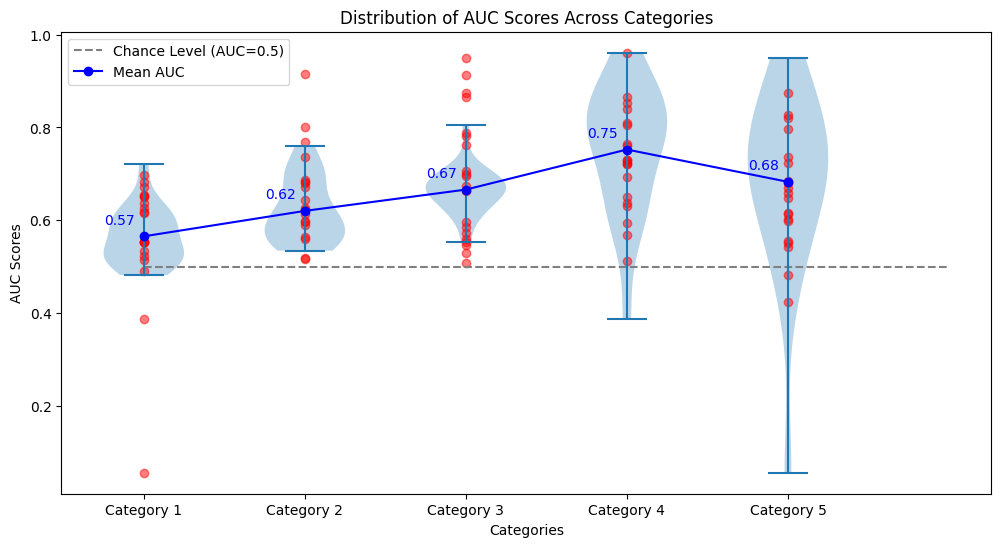

In [9]:
# violinplot and rainplot of AUC scores across categories for each part
auc_scores_per_category = {cat: [auc_scores[part][cat] for part in auc_scores] for cat in range(1, 6)}
print(f'average AUC scores per category: { {cat: np.mean(auc_scores_per_category[cat]) for cat in auc_scores_per_category} }')

plt.figure(figsize=(12, 6))
plt.plot([1,6], [0.5, 0.5], color='gray', linestyle='--', label='Chance Level (AUC=0.5)')
plt.violinplot([auc_scores_per_category[cat] for cat in auc_scores_per_category], positions=range(1, 6))
plt.scatter(np.repeat(range(1, 6), len(auc_scores)), [auc_scores[part][cat] for part in auc_scores for cat in range(1, 6)], color='red', alpha=0.5)
plt.plot(list(range(1, 6)), [np.mean(auc_scores_per_category[cat]) for cat in range(1, 6)], color='blue', marker='o', linestyle='-', label='Mean AUC')
for cat in range(1, 6):
    mean_auc = np.mean(auc_scores_per_category[cat])
    plt.text(cat-0.15, mean_auc + 0.02, f'{mean_auc:.2f}', ha='center', va='bottom', fontsize=10, color='blue')
plt.xlabel('Categories')
plt.ylabel('AUC Scores')
plt.title('Distribution of AUC Scores Across Categories')
plt.xticks(range(1, 6), [f'Category {i}' for i in range(1, 6)])
plt.legend()
plt.show()